In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Phase 1: Problem & Data Foundations

Problem statement, dataset selection, EDA, and metric definition


In [2]:
df=pd.read_csv('predictive_maintenance.csv')
df.head(5)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  object 
dtypes: float64(3), int64(4), object(3)
memory usage: 781.4+ KB


In [4]:
df.describe()


,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000


In [5]:
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Target                     0
Failure Type               0
dtype: int64

In [6]:
df.columns


Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Target', 'Failure Type'],
      dtype='object')

In [7]:
df['Target'].value_counts(normalize=True)


Target
0    0.9661
1    0.0339
Name: proportion, dtype: float64

In [8]:
df.rename(columns={'Target': 'Failure'}, inplace=True)


In [9]:
X = df.drop('Failure', axis=1)
X = X.drop(columns=["UDI", "Product ID"], errors="ignore")
y = df['Failure']


In [10]:
df['Type'] = df['Type'].astype('category')


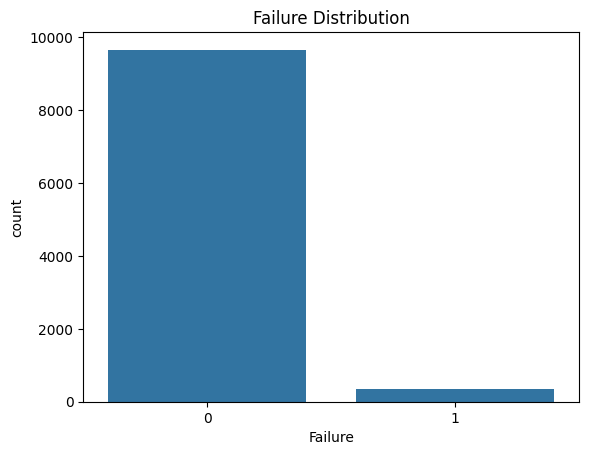

In [11]:
sns.countplot(data=df, x='Failure')
plt.title("Failure Distribution")
plt.show()


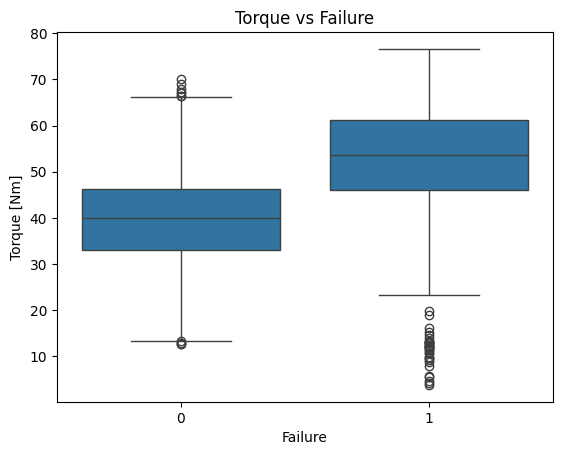

In [12]:
sns.boxplot(data=df, x='Failure', y='Torque [Nm]')
plt.title("Torque vs Failure")
plt.show()


# Phase 1 Report 

## Objective
The objective of this phase is to understand the dataset, identify patterns, and prepare clean data for machine learning modeling.

## Tasks Performed
- Loaded the predictive maintenance dataset.
- Explored dataset structure and summary statistics.
- Checked missing values and corrected inconsistencies.
- Analyzed feature distributions and relationships.
- Cleaned and transformed dataset for modeling.
- Identified target variable representing machine failure.

## Observations
- Dataset includes operational parameters such as air temperature, process temperature, torque, rotational speed, and tool wear.
- Machine operational characteristics influence failure probability.
- Data preprocessing was required before training models.

## Outcome
At the end of this phase:
- Dataset was cleaned and structured.
- Target and feature variables were defined.
- Data became suitable for machine learning model training.


# Phase 2: Modeling & Explainability

Multiple ML models, feature engineering, hyperparameter tuning, and interpretability

In [13]:
from sklearn.model_selection import train_test_split

In [14]:
X = df.drop('Failure', axis=1)
y = df['Failure']



In [15]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(X_train.shape, X_val.shape, X_test.shape)

(7000, 9) (1500, 9) (1500, 9)


In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

num_cols = ['Air temperature [K]',
            'Process temperature [K]',
            'Rotational speed [rpm]',
            'Torque [Nm]',
            'Tool wear [min]']

cat_cols = ['Type']

preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ])


In [17]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [18]:
log_clf = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', LogisticRegression(max_iter=1000))
])

log_clf.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Air temperature [K]',
                                                   'Process temperature [K]',
                                                   'Rotational speed [rpm]',
                                                   'Torque [Nm]',
                                                   'Tool wear [min]']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Type'])])),
                ('model', LogisticRegression(max_iter=1000))])

In [19]:
from sklearn.svm import SVC

In [20]:
svm_clf = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', SVC(probability=True))
])

svm_clf.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Air temperature [K]',
                                                   'Process temperature [K]',
                                                   'Rotational speed [rpm]',
                                                   'Torque [Nm]',
                                                   'Tool wear [min]']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Type'])])),
                ('model', SVC(probability=True))])

In [21]:
from sklearn.ensemble import RandomForestClassifier

In [22]:
rf_clf = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', RandomForestClassifier())
])

rf_clf.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Air temperature [K]',
                                                   'Process temperature [K]',
                                                   'Rotational speed [rpm]',
                                                   'Torque [Nm]',
                                                   'Tool wear [min]']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Type'])])),
                ('model', RandomForestClassifier())])

In [23]:
from sklearn.neighbors import KNeighborsClassifier

In [24]:
knn_clf = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', KNeighborsClassifier())
])

knn_clf.fit(X_train, y_train)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Air temperature [K]',
                                                   'Process temperature [K]',
                                                   'Rotational speed [rpm]',
                                                   'Torque [Nm]',
                                                   'Tool wear [min]']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Type'])])),
                ('model', KNeighborsClassifier())])

In [25]:
from sklearn.naive_bayes import GaussianNB

In [26]:
nb_clf = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', GaussianNB())
])

nb_clf.fit(X_train, y_train)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Air temperature [K]',
                                                   'Process temperature [K]',
                                                   'Rotational speed [rpm]',
                                                   'Torque [Nm]',
                                                   'Tool wear [min]']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Type'])])),
                ('model', GaussianNB())])

In [27]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

In [28]:
def evaluate(model, X_val, y_val):
    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)[:,1]
    return {
        'Accuracy': accuracy_score(y_val, y_pred),
        'Precision': precision_score(y_val, y_pred),
        'Recall': recall_score(y_val, y_pred),
        'F1': f1_score(y_val, y_pred),
        'ROC_AUC': roc_auc_score(y_val, y_prob)
    }


In [29]:
models = {
    'Logistic Regression': log_clf,
    'SVM': svm_clf,
    'Random Forest': rf_clf,
    'KNN': knn_clf,
    'Naive Bayes': nb_clf
}

results = {name: evaluate(model, X_val, y_val) for name, model in models.items()}
results


{'Logistic Regression': {'Accuracy': 0.968,
  'Precision': 0.6363636363636364,
  'Recall': 0.13725490196078433,
  'F1': 0.22580645161290322,
  'ROC_AUC': np.float64(0.8621767547598749)},
 'SVM': {'Accuracy': 0.9706666666666667,
  'Precision': 0.8181818181818182,
  'Recall': 0.17647058823529413,
  'F1': 0.2903225806451613,
  'ROC_AUC': np.float64(0.9439505270707317)},
 'Random Forest': {'Accuracy': 0.9773333333333334,
  'Precision': 0.7575757575757576,
  'Recall': 0.49019607843137253,
  'F1': 0.5952380952380952,
  'ROC_AUC': np.float64(0.970777683053898)},
 'KNN': {'Accuracy': 0.97,
  'Precision': 0.65,
  'Recall': 0.2549019607843137,
  'F1': 0.36619718309859156,
  'ROC_AUC': np.float64(0.8352413429139773)},
 'Naive Bayes': {'Accuracy': 0.954,
  'Precision': 0.25,
  'Recall': 0.17647058823529413,
  'F1': 0.20689655172413793,
  'ROC_AUC': np.float64(0.8291045886953816)}}

In [30]:
from sklearn.model_selection import GridSearchCV

rf_params = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [None, 5, 10, 20],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}

rf_grid = GridSearchCV(
    estimator=rf_clf,
    param_grid=rf_params,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    verbose=2
)

rf_grid.fit(X_train, y_train)

print("Best RF Params:", rf_grid.best_params_)
print("Best RF CV ROC-AUC:", rf_grid.best_score_)


Fitting 3 folds for each of 108 candidates, totalling 324 fits


C:\Users\jitendra khandelwal\anaconda3\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best RF Params: {'model__max_depth': 20, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 200}
Best RF CV ROC-AUC: 0.971118871616974


In [31]:
y_pred_rf = rf_grid.predict(X_val)
y_prob_rf = rf_grid.predict_proba(X_val)[:,1]

from sklearn.metrics import roc_auc_score, classification_report
print("Validation ROC-AUC:", roc_auc_score(y_val, y_prob_rf))
print(classification_report(y_val, y_pred_rf))


Validation ROC-AUC: 0.9770294591266457
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1449
           1       0.76      0.43      0.55        51

    accuracy                           0.98      1500
   macro avg       0.87      0.71      0.77      1500
weighted avg       0.97      0.98      0.97      1500



In [32]:
svm_params = {
    'model__C': [0.1, 1, 10],
    'model__kernel': ['linear', 'rbf'],
    'model__gamma': ['scale', 'auto']
}

svm_grid = GridSearchCV(
    estimator=svm_clf,
    param_grid=svm_params,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    verbose=2
)

svm_grid.fit(X_train, y_train)

print("Best SVM Params:", svm_grid.best_params_)
print("Best SVM CV ROC-AUC:", svm_grid.best_score_)


Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best SVM Params: {'model__C': 10, 'model__gamma': 'auto', 'model__kernel': 'rbf'}
Best SVM CV ROC-AUC: 0.9540425633721816


In [33]:
y_pred_svm = svm_grid.predict(X_val)
y_prob_svm = svm_grid.predict_proba(X_val)[:,1]

print("Validation ROC-AUC:", roc_auc_score(y_val, y_prob_svm))
print(classification_report(y_val, y_pred_svm))


Validation ROC-AUC: 0.9632606665854747
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1449
           1       0.80      0.47      0.59        51

    accuracy                           0.98      1500
   macro avg       0.89      0.73      0.79      1500
weighted avg       0.98      0.98      0.98      1500



In [34]:
tuned_results = {
    'Random Forest (tuned)': roc_auc_score(y_val, y_prob_rf),
    'SVM (tuned)': roc_auc_score(y_val, y_prob_svm)
}

tuned_results


{'Random Forest (tuned)': np.float64(0.9770294591266457),
 'SVM (tuned)': np.float64(0.9632606665854747)}

In [35]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

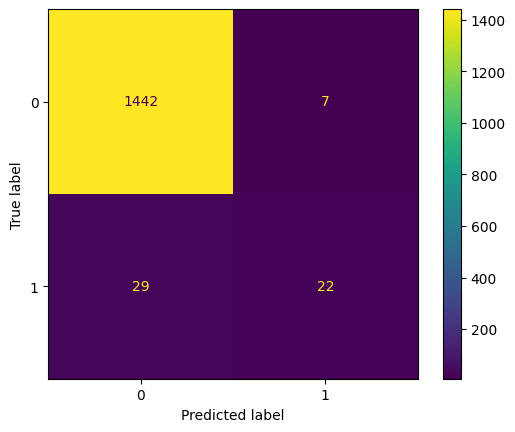

In [36]:
best_model = rf_grid.best_estimator_

y_pred = best_model.predict(X_val)

cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()


In [37]:
# extract the model without preprocessing
model = best_model.named_steps['model']

# get feature names after preprocessing
ohe = best_model.named_steps['preprocess'].named_transformers_['cat']
num_features = num_cols
cat_features = ohe.get_feature_names_out(cat_cols)

all_features = np.concatenate([num_features, cat_features])

importances = model.feature_importances_

feature_importance = pd.DataFrame({
    'feature': all_features,
    'importance': importances
}).sort_values('importance', ascending=False)

feature_importance

,feature,importance
3,Torque [Nm],0.362342
2,Rotational speed [rpm],0.237374
4,Tool wear [min],0.158690
0,Air temperature [K],0.110402
1,Process temperature [K],0.110256
6,Type_L,0.010077
7,Type_M,0.007850
5,Type_H,0.003008


# Phase 2 Report

## Objective
Train and evaluate machine learning models to accurately predict machine failures.

## Tasks Performed
- Split dataset into training and testing sets.
- Built preprocessing pipeline using ColumnTransformer.
- Trained multiple machine learning models.
- Compared models using evaluation metrics.
- Applied hyperparameter tuning to improve performance.
- Selected the best-performing model.

## Observations
- Ensemble models performed better due to handling complex feature interactions.
- Proper preprocessing significantly improved model performance.

## Outcome
At the end of this phase:
- Best predictive model was selected.
- Preprocessing and model pipeline were created.
- Model achieved reliable prediction accuracy.


# Phase 3: Deployment & MLOps

Streamlit app, Hugging Face deployment, MLflow tracking, and Prefect pipelines

In [38]:
from sklearn.pipeline import Pipeline
import joblib

pipeline = Pipeline([
    ("preprocess", preprocess),
    ("model", rf_clf)
])

joblib.dump(pipeline, "pipeline.pkl", protocol=4)
joblib.dump(X_train.columns.tolist(), "columns.pkl", protocol=4)

print("Pipeline saved!")


Pipeline saved!


In [39]:
num_cols = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

cat_cols = ["Type"]

preprocess = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

pipeline = Pipeline([
    ("preprocess", preprocess),
    ("model", RandomForestClassifier())
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

pipeline.fit(X_train, y_train)

joblib.dump(pipeline, "pipeline.pkl")
joblib.dump(X_train.columns.tolist(), "columns.pkl")

['columns.pkl']